In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [2]:
X,y_true = make_blobs(n_samples=500,centers=3,cluster_std=0.60,random_state=42)

In [4]:
df = pd.DataFrame(X,columns=['Feature_1','Feature_2'])

In [5]:
df

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [7]:
inertia = [] #WCSS
K_range = range(1,11)

In [8]:
for k in K_range:
    Kmeans = KMeans(n_clusters=k,random_state=42)
    Kmeans.fit(X_scaled)
    inertia.append(Kmeans.inertia_)

In [10]:
inertia

[1000.0000000000001,
 297.89541410517216,
 11.57548472310498,
 9.752067977356841,
 8.257175272446283,
 6.917577320416799,
 6.334755391595288,
 5.704177177901429,
 5.060234133532076,
 4.762361898130396]

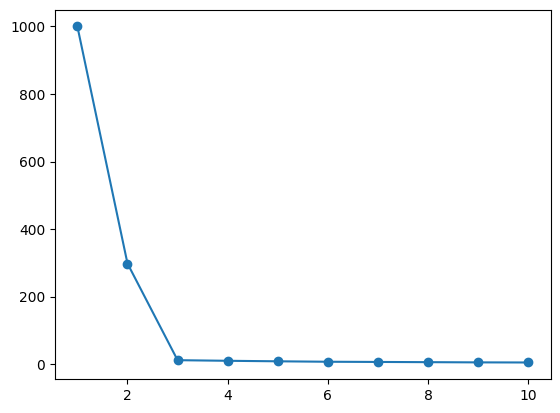

In [12]:
plt.plot(K_range,inertia,marker = 'o')

In [ ]:
kmeans_final = KMeans(n_clusters = 3,random_state = 42)


In [15]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [16]:
df['cluster'] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

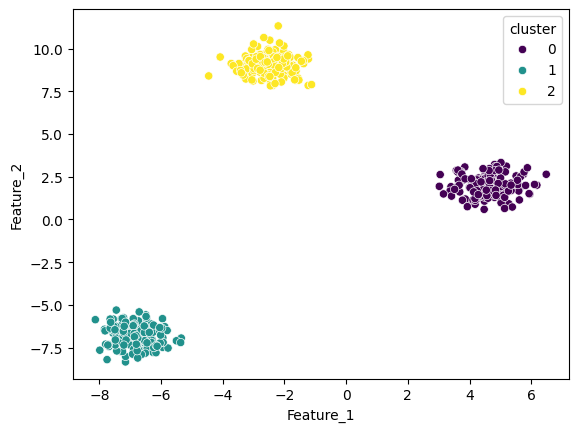

In [17]:
sns.scatterplot(x=df['Feature_1'],
                y=df['Feature_2'],
                hue=df['cluster'],
                palette='viridis')

In [33]:
from sklearn.datasets import make_moons

In [34]:
X,y_true = make_moons(n_samples=500,noise=0.05,random_state=42)

In [43]:
from sklearn.cluster import KMeans,DBSCAN

In [37]:
df = pd.DataFrame(X,columns=['Feature_1','Feature_2'])

In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [39]:
Kmeans = KMeans(n_clusters=2,random_state=42)
Kmeans_lables = Kmeans.fit_predict(X_scaled)


In [40]:
df['Kmeans_cluster'] = Kmeans_lables

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

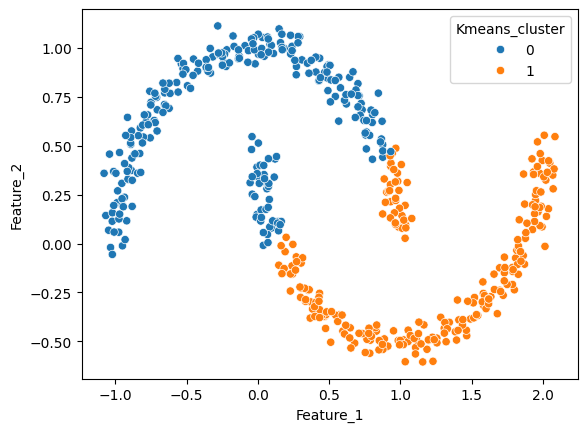

In [41]:
sns.scatterplot(x=df['Feature_1'],
                y=df['Feature_2'],
                hue=df['Kmeans_cluster'],
                palette='tab10')

In [44]:
dbscan = DBSCAN(eps=0.3,min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled) 

In [45]:
df['dbscan_cluster'] = dbscan_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

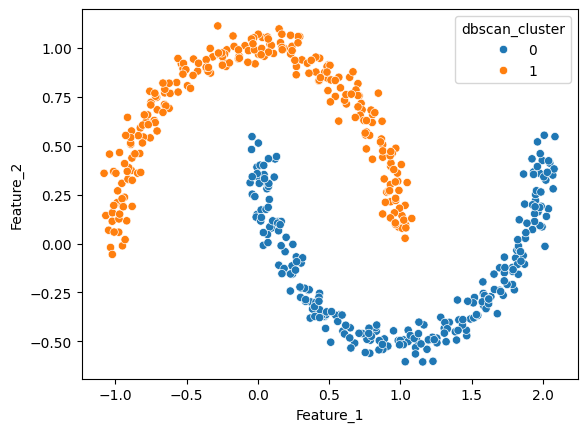

In [46]:
sns.scatterplot(x=df['Feature_1'],
                y=df['Feature_2'],
                hue=df['dbscan_cluster'],
                palette='tab10')

PCA

In [51]:
from sklearn.decomposition import PCA

In [52]:
X,y = make_blobs(n_samples=500,n_features=5,centers=3,cluster_std=1.5,random_state=42)

In [53]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [54]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [55]:
df_pca = pd.DataFrame(X_pca,columns=['PC1','PC2'])
df_pca['label'] = y

<Axes: xlabel='PC1', ylabel='PC2'>

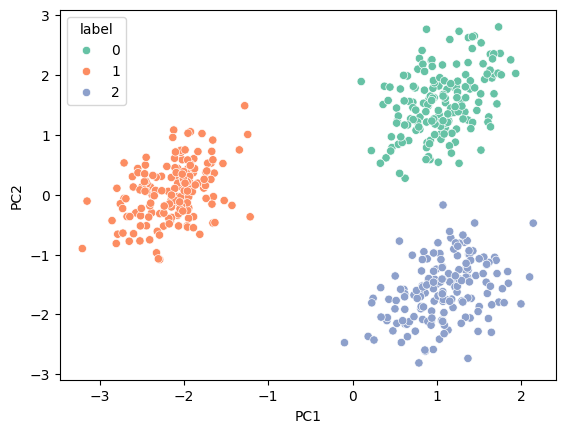

In [56]:
sns.scatterplot(data=df_pca,x='PC1',y='PC2',hue='label',palette='Set2')